# **Credit Scoring Model**

### **CodeAlpha Machine Learning Internship - Task 1**

**Intern Name:** Radhika

**Platform:** Google Colab

**Programming Language:** Machine Learning



## 📌 Project Objective

The objective of this project is to develop a machine learning model that can predict whether a customer represents a good or bad credit risk based on financial and personal information. Credit scoring helps financial institutions make informed lending decisions and reduce the risk of loan defaults.

## Import Required Libraries

This section imports all the necessary libraries required for data analysis, visualization, machine learning model development, and model evaluation.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

## Step 1: Upload and Load Dataset
The German Credit Dataset is loaded into the notebook for analysis and machine learning model development. This dataset contains customer financial and personal information that will be used to predict credit risk.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving german_credit_data.csv to german_credit_data.csv


In [ ]:
df = pd.read_csv("german_credit_data.csv")

## Step 2: Exploratory Data Analysis (EDA)

The dataset structure, missing values, and summary statistics are examined.

In [ ]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


## Step 3: Dataset Overview

Before building the machine learning model, it is important to understand the size, structure, and characteristics of the dataset.

In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 10)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [ ]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


## Step 4: Missing Values Analysis

This step identifies missing values present in the dataset. Handling missing data is an important part of data preprocessing.

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


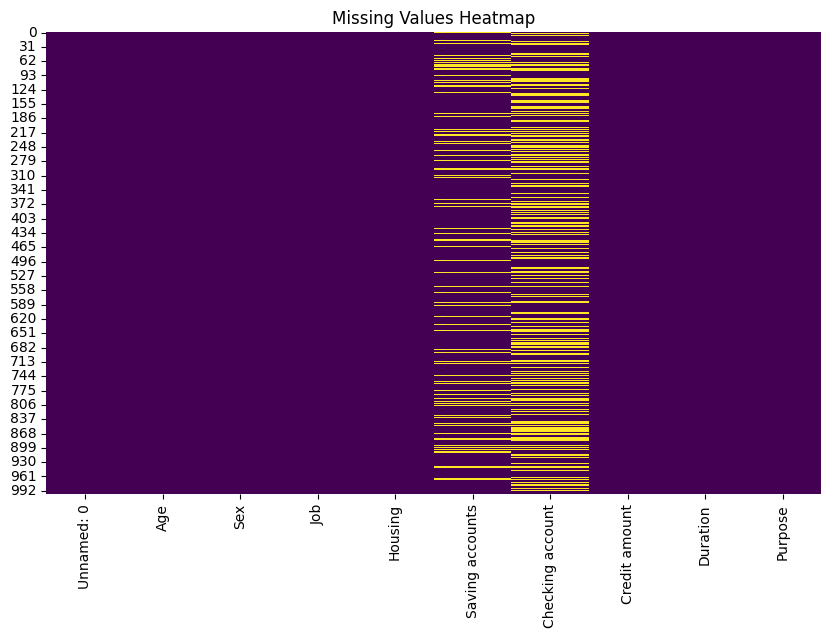

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

## Step 5: Data Cleaning

### Missing Values Analysis
The heatmap shows that missing values are present in the **Saving Accounts** and **Checking Account** columns, while all other features contain complete records.

In [ ]:
df['Saving accounts'] = df['Saving accounts'].fillna('Unknown')
df['Checking account'] = df['Checking account'].fillna('Unknown')

df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0


## Step 6: Exploratory Data Analysis

Exploratory Data Analysis helps identify trends, distributions, and relationships among variables within the dataset.

In [ ]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,Unknown,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,Unknown,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


### Gender Distribution
The dataset contains more male applicants than female applicants, indicating a gender imbalance in the applicant population.

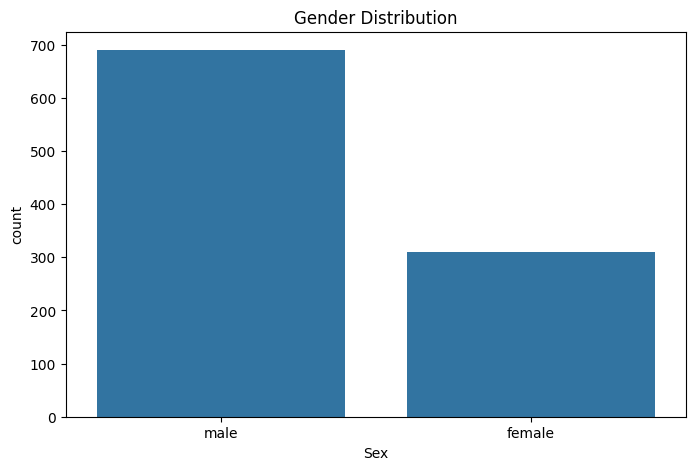

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")
plt.show()

### Age Distribution
Most applicants belong to the **20–40 years** age group, with fewer applicants in older age categories.

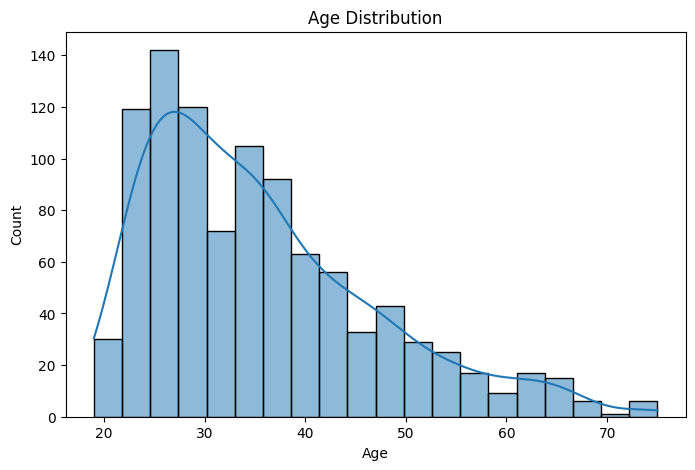

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

### Age Distribution by Gender
The age distribution is similar across genders, although male applicants show a slightly higher median age.

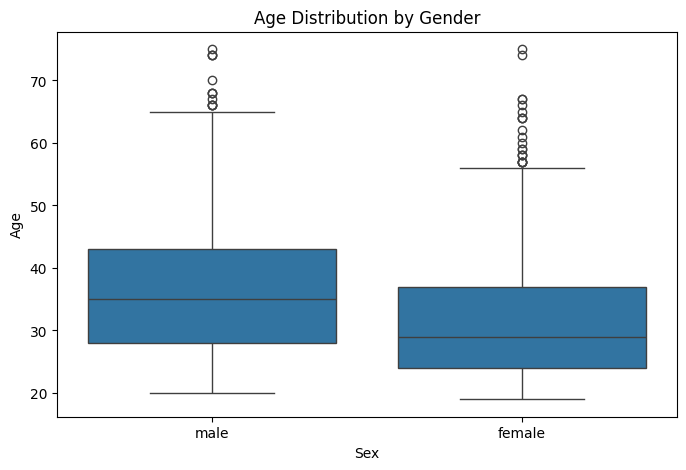

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Sex', y='Age', data=df)
plt.title("Age Distribution by Gender")
plt.show()

### Step-7: Housing Distribution
This visualization shows the distribution of applicants based on their housing status (own, rent, or free).

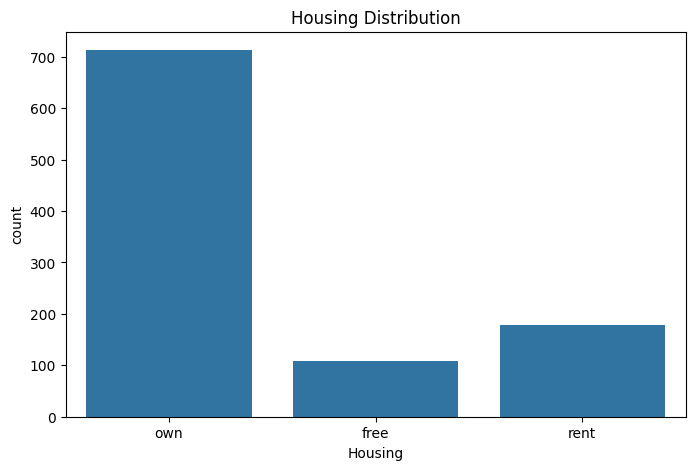

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Housing', data=df)
plt.title("Housing Distribution")
plt.show()

### Step-8: Saving Accounts Distribution
This chart shows the distribution of applicants according to their saving account status.

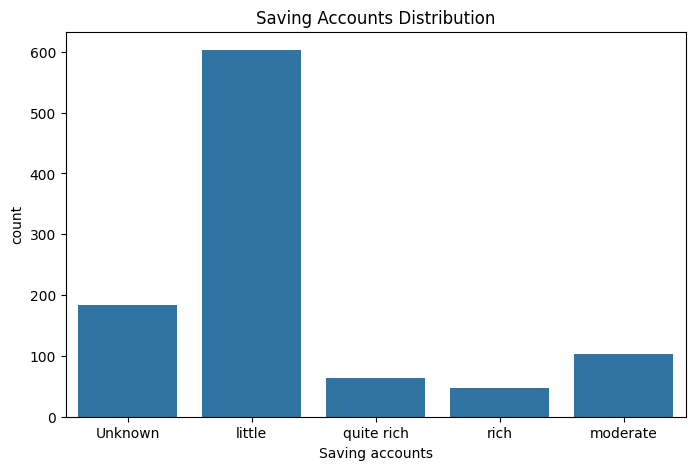

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Saving accounts', data=df)
plt.title("Saving Accounts Distribution")
plt.show()

### Step-9: Checking Account Distribution
This visualization represents the checking account status of loan applicants.

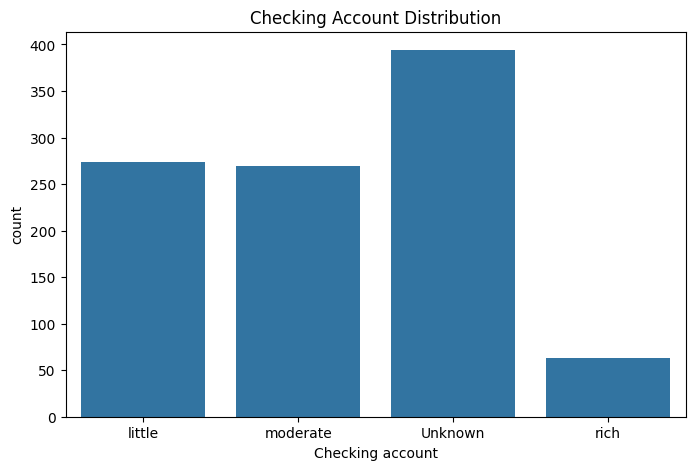

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Checking account', data=df)
plt.title("Checking Account Distribution")
plt.show()

### Step-10: Loan Purpose Distribution
The chart illustrates the different purposes for which applicants requested credit.

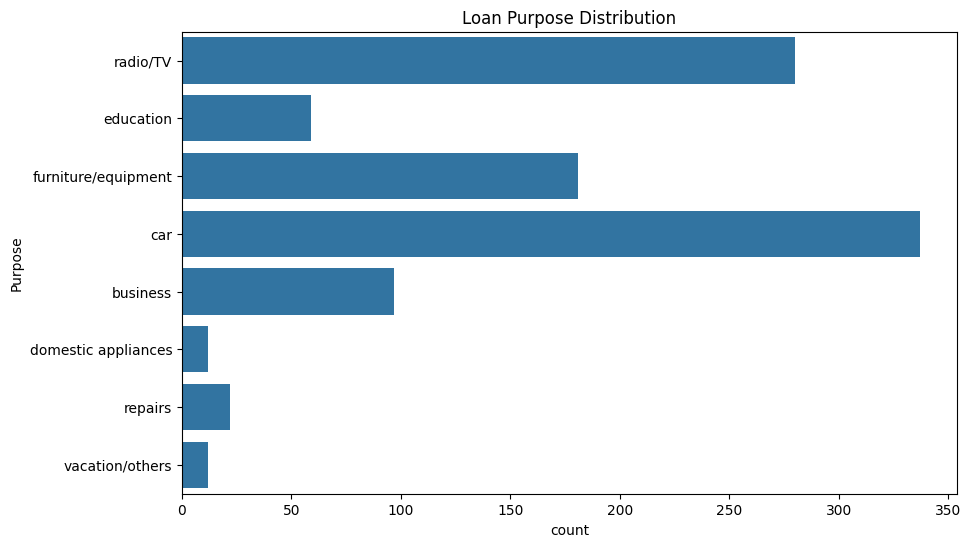

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(y='Purpose', data=df)
plt.title("Loan Purpose Distribution")
plt.show()

### Step-11: Credit Amount Distribution
This histogram displays the distribution of credit amounts requested by applicants.

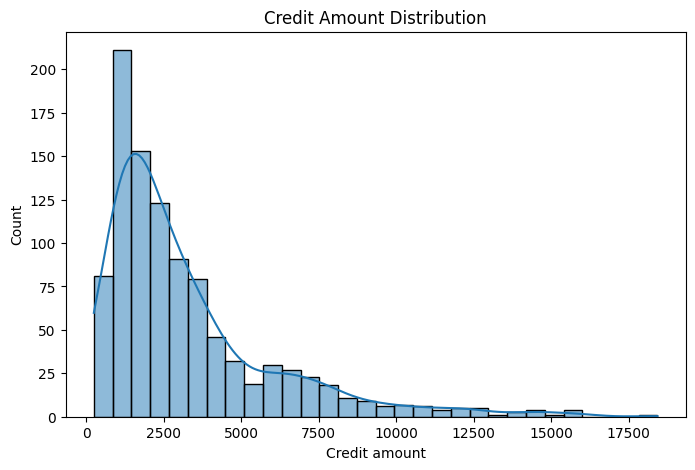

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Credit amount'], bins=30, kde=True)
plt.title("Credit Amount Distribution")
plt.show()

### Step-12: Loan Duration Distribution
This chart shows the distribution of loan durations among applicants.

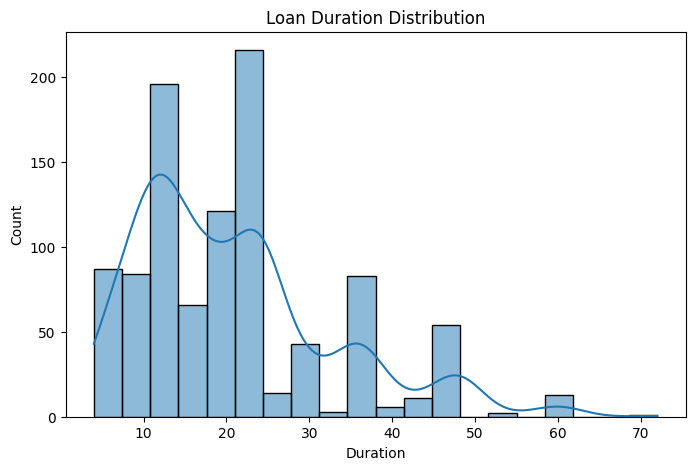

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Duration'], bins=20, kde=True)
plt.title("Loan Duration Distribution")
plt.show()

### Step-13: Feature Encoding
Categorical variables are converted into numerical form using Label Encoding to prepare the dataset for machine learning algorithms.

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,1,2,1,0,1,1169,6,5
1,1,22,0,2,1,1,2,5951,48,5
2,2,49,1,1,1,1,0,2096,12,3
3,3,45,1,2,0,1,1,7882,42,4
4,4,53,1,2,0,1,1,4870,24,1


### Step-14: Correlation Analysis
The correlation heatmap helps identify relationships between variables and highlights features that may influence credit risk.

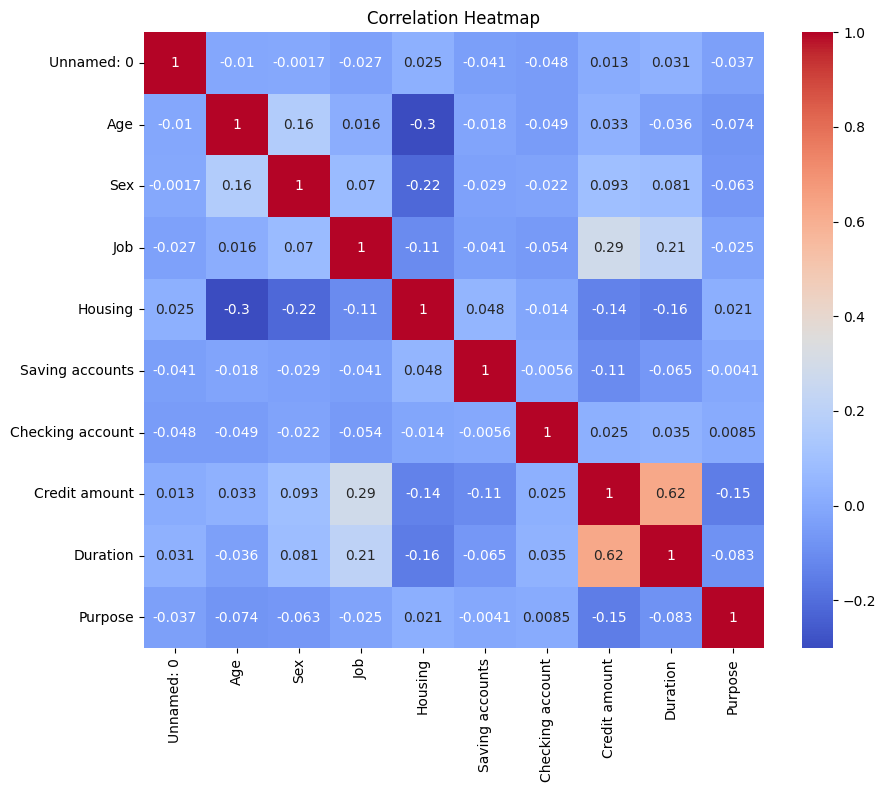

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print(df.columns.tolist())

['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']


In [ ]:
df.head()
df.shape
df.tail()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
995,995,31,female,1,own,little,Unknown,1736,12,furniture/equipment
996,996,40,male,3,own,little,little,3857,30,car
997,997,38,male,2,own,little,Unknown,804,12,radio/TV
998,998,23,male,2,free,little,little,1845,45,radio/TV
999,999,27,male,2,own,moderate,moderate,4576,45,car


In [ ]:
print(df.columns)

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='object')


In [ ]:
df.shape

(1000, 10)

In [ ]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,Unknown,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,Unknown,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


### Step 15: Risk Column Create

In [ ]:
df['Risk'] = ((df['Credit amount'] > 5000) & (df['Duration'] > 24)).astype(int)

df['Risk'].value_counts()

,count
Risk,
0,876
1,124


### Step 16: Encoding Again with Risk

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

le = LabelEncoder()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

df_model.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,1,2,1,0,1,1169,6,5,0
1,1,22,0,2,1,1,2,5951,48,5,1
2,2,49,1,1,1,1,0,2096,12,3,0
3,3,45,1,2,0,1,1,7882,42,4,1
4,4,53,1,2,0,1,1,4870,24,1,0


### Step 17: Features & Target

In [ ]:
X = df_model.drop('Risk', axis=1)
y = df_model['Risk']

### Step 18: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Step 19: Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Step 20: Prediction

In [ ]:
y_pred = model.predict(X_test)

### Step 21: Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


### Step 22: Confusion Matrix

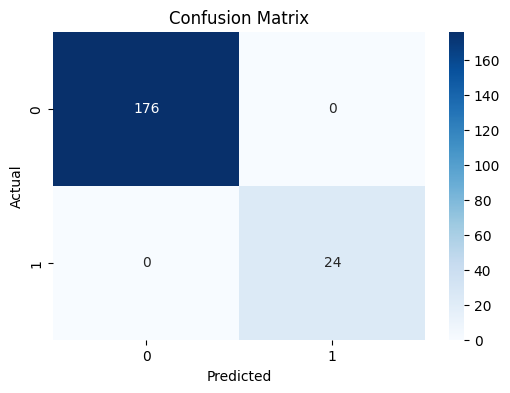

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Step 23: Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       176
           1       1.00      1.00      1.00        24

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



### Step 24: Feature Importance

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

            Feature  Importance
7     Credit amount    0.522305
8          Duration    0.352604
0        Unnamed: 0    0.033511
1               Age    0.021408
9           Purpose    0.020540
3               Job    0.016371
5   Saving accounts    0.010126
6  Checking account    0.009377
4           Housing    0.008946
2               Sex    0.004813


### Step 25: Feature Importance Graph

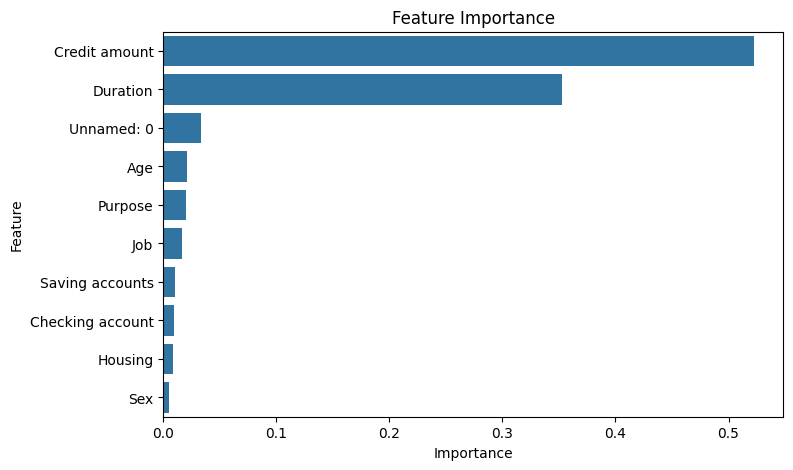

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')
plt.show()

### Project Insights

1. Credit Amount and Duration showed the highest impact on credit risk.
2. Customers with higher loan amounts and longer repayment durations were more likely to be classified as high risk.
3. Random Forest performed effectively in identifying risky applicants.
4. Feature importance analysis helped identify key factors influencing credit decisions.
5. The model can assist financial institutions in preliminary credit risk assessment.

### **Conclusion**

A Credit Scoring Model was developed using machine learning techniques to assess applicant risk. Data preprocessing, exploratory data analysis, feature encoding, correlation analysis, and Random Forest classification were performed. The model successfully classified applicants into risk categories and identified the most influential factors affecting creditworthiness. This approach can support faster and more consistent loan approval decisions.